In [1]:
from numpy import nan
from pandas import read_csv,DataFrame
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score,f1_score,ConfusionMatrixDisplay,RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

import joblib

In [3]:
df = read_csv('diabetes.csv')

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

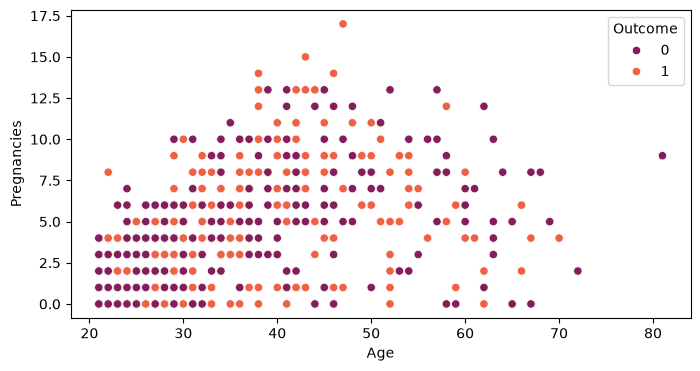

In [12]:
plt.figure(figsize=(8,4))
sns.scatterplot(df,x="Age",y="Pregnancies",hue="Outcome",palette="rocket")
plt.savefig(f"images/scatterplot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

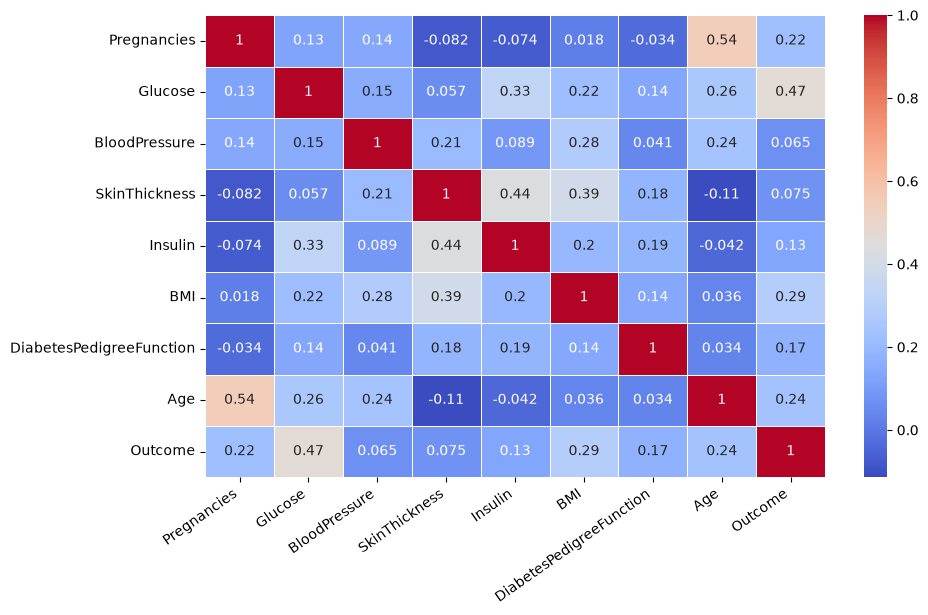

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",fmt='.2g',annot=True,linewidths=0.5)
plt.xticks(rotation=35, ha="right")
plt.savefig(f"images/heatmap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

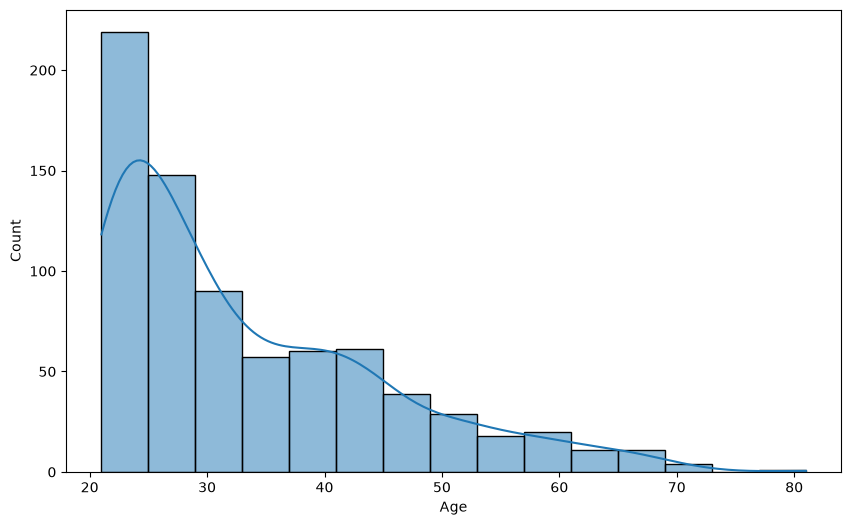

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df,x="Age",kde=True,bins=15)
plt.savefig(f"images/histplot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

Outcome
0    500
1    268
Name: count, dtype: int64


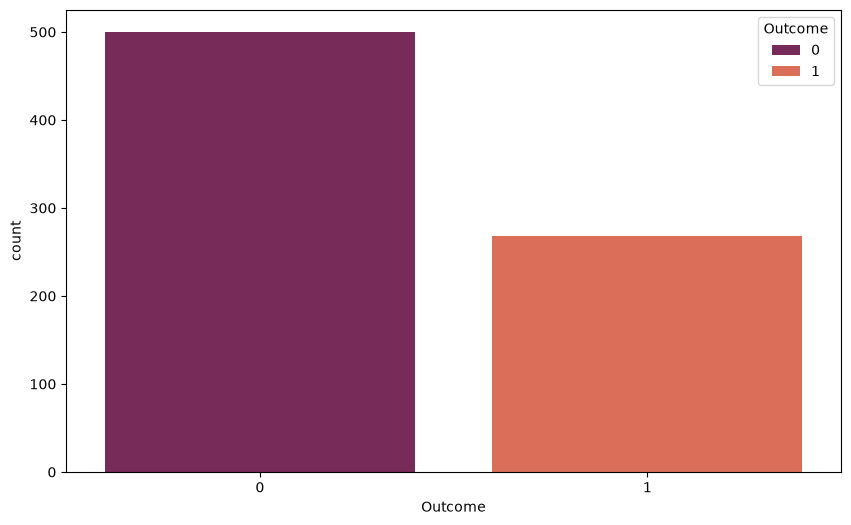

In [15]:
print(df["Outcome"].value_counts())
plt.figure(figsize=(10,6))
sns.countplot(df,x="Outcome",palette="rocket",hue="Outcome")
plt.savefig(f"images/countplot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

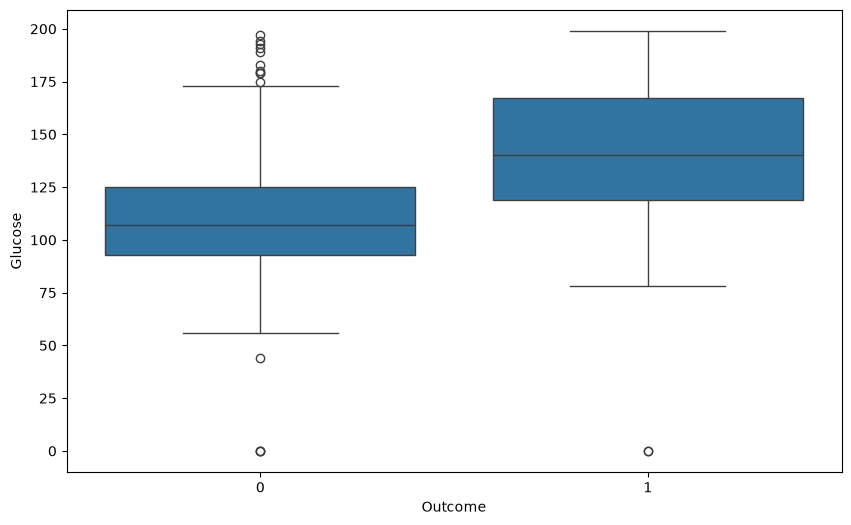

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Outcome", y="Glucose")
plt.savefig(f"images/boxplot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [17]:
df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']]=df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0,nan)

In [18]:
X,y = df.drop("Outcome",axis=1),df["Outcome"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=2)

In [19]:
pipe = Pipeline([("impute",SimpleImputer(strategy='median')),("scaler",StandardScaler()),("model",LogisticRegression())])

In [20]:
param = [
    {
        "scaler":[StandardScaler(),RobustScaler()],
        "model": [LogisticRegression()],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear", "saga"],
        "model__max_iter": [500, 1000]
    },

    {
        "scaler":["passthrough"],
        "model": [RandomForestClassifier()],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]
    },

    {
        "scaler":["passthrough"],
        "model": [GradientBoostingClassifier()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2, 4]
    },

    {
        "scaler":["passthrough"],
        "model": [XGBClassifier()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__min_child_weight": [1, 3, 5],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
]

In [23]:
grid = RandomizedSearchCV(pipe,param,n_iter=30,cv=5,n_jobs=-1,verbose=1,scoring='roc_auc')

In [24]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [LogisticRegression()], 'model__C': [0.01, 0.1, ...], 'model__max_iter': [500, 1000], 'model__penalty': ['l1', 'l2'], ...}, {'model': [RandomForestClassifier()], 'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the ret

In [25]:
best = grid.best_estimator_
print(grid.best_score_)
print(grid.best_params_)
print(grid.best_estimator_)

y_pred =best.predict(x_test)
y_prob =best.predict_proba(x_test)[:,1]
# y_pred = (y_prob >= 0.3).astype(int)

0.8409821759136827
{'scaler': StandardScaler(), 'model__solver': 'saga', 'model__penalty': 'l2', 'model__max_iter': 1000, 'model__C': 1, 'model': LogisticRegression()}
Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=1, max_iter=1000, penalty='l2',
                                    solver='saga'))])


In [26]:
acc = accuracy_score(y_test,y_pred)
pr = precision_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_prob)
re = recall_score(y_test,y_pred)


p = {
    "accuracy_score":acc*100,
    "precision_score":pr*100,
    "f1_score":f1*100,
    "roc_auc_score":roc*100,
    "recall_score":re*100
}

p = DataFrame(p,index=[''])
p

,accuracy_score,precision_score,f1_score,roc_auc_score,recall_score
,76.5625,65.116279,55.445545,80.790015,48.275862


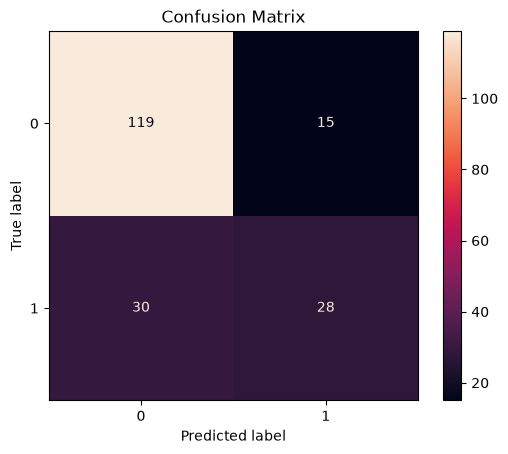

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="rocket")

plt.title("Confusion Matrix")
plt.show()

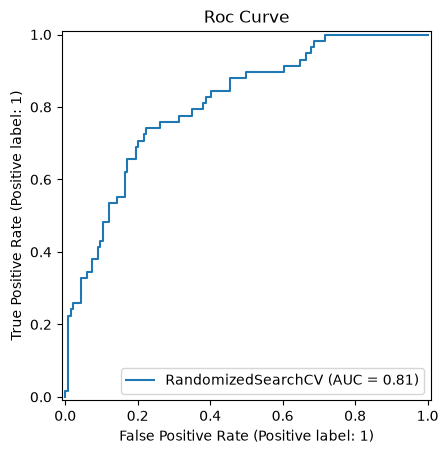

In [28]:
RocCurveDisplay.from_estimator(grid,x_test,y_test)
plt.title("Roc Curve")
plt.show()

In [29]:
joblib.dump(grid.best_estimator_,"models/diabetes_model.joblib")

['models/diabetes_model.joblib']